In [25]:
#0 Imports
#  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.signal import resample
import sqlite3


In [56]:
#Constants

# MediaPipe / BlazePose joint indices (33 joints)
LEFT_HIP = 23
RIGHT_HIP = 24
LEFT_SHOULDER = 11
RIGHT_SHOULDER = 12
LEFT_KNEE = 25
RIGHT_KNEE = 26
LEFT_ANKLE = 27
RIGHT_ANKLE = 28


In [42]:
# 0 Load data as csv from MediaPipe Pose from database

#Connect to database
db_path = "../landmark_database.db"
conn = sqlite3.connect(db_path)

#==========================================
#BASIC QUERIES
#==========================================
#View all data (limit to first 1000 rows)
df = pd.read_sql_query("SELECT * FROM landmarks LIMIT 2000000 OFFSET 20000000", conn)
print(f"Total rows loaded: {len(df)}")
df.head()

Test_data = df.copy()

#Get specific patient data
#patient_df = pd.read_sql_query("""
#    SELECT * FROM landmarks 
#""", conn)

#df.head()

#Rows: 21,850,000 - 22,050,000

Total rows loaded: 1906020


In [81]:
df_healthy = pd.read_sql_query("SELECT * FROM landmarks LIMIT 1000000", conn)
print(f"Total rows loaded: {len(df)}")
df.head()

Test_data_healthy = df_healthy.copy()


Total rows loaded: 1906020


In [1]:
Test_data.Head(100)

NameError: name 'Test_data' is not defined

In [44]:
# 1 Convert pose coordinates into pose column

def add_pose_column(df):
    pose_rows = []

    for source_file, group in df.groupby('source_file'):
        group = group.sort_values('frame')

        frames = np.sort(group['frame'].unique())
        frame_to_idx = {f: i for i, f in enumerate(frames)}

        T = len(frames)
        J = group['landmark_id'].nunique()

        pose = np.zeros((T, J, 3))

        for _, r in group.iterrows():
            f_idx = frame_to_idx[r.frame]
            j = int(r.landmark_id)
            pose[f_idx, j, :] = [r.x_norm, r.y_norm, r.z_norm]

        row = group.iloc[0].copy()
        row['pose'] = pose
        pose_rows.append(row)

    return pd.DataFrame(pose_rows)

In [45]:
# 2. Normalize the Pose

def normalize_pose_3d(pose):
    #pose: (T,J,3)
    
    # Joint indices
    LEFT_HIP = 23
    RIGHT_HIP = 24
    LEFT_SHOULDER = 11
    RIGHT_SHOULDER = 12
    
    pelvis = (pose[:, LEFT_HIP]+ pose[:, LEFT_HIP]) / 2

    #Translate: Express every joint position relative to the pelvis at each moment in time. Removing the pelvis position from all joints positions per frame centers the pose data dynamically. 
    # It remove the following effects: camera panning: distance-to.camera-effects, subject walking across the frame. 
    # What remains are relative joint motion, inter-limb coordination, postural deviations.
    pose_centered = pose - pelvis[:, None, :]
    # pose.shape == (T,J,3), pelvis.shape == (T,3). The above takes all frames, adds a new placeholder axis, then takes x,y coordinates -> (T,1,3).

    #Scale by torso length per frame
    # These joints are: more stable during gait, rarely occluded, Less noisy or affected by pathology than joints used for leg length measure,

    torso = (pose_centered[:, LEFT_SHOULDER] + pose_centered[:, RIGHT_SHOULDER]) / 2
    
    scale = np.linalg.norm(torso - pelvis, axis=1).mean() #calculates the torso length based on the average measures across time to get stable scale per clip.
    pose_scaled = pose_centered / scale # All coordinates are now expressed in units of torso_length, making them more comparable across subjects

    return pose_scaled

"""
#Removed:
✔ Body size differences
✔ Camera distance effects
Preserved:
✔ Relative joint motion
✔ Asymmetry
✔ Trunk lean & pelvic drop
✔ Temporal dynamics
"""


'\n#Removed:\n✔ Body size differences\n✔ Camera distance effects\nPreserved:\n✔ Relative joint motion\n✔ Asymmetry\n✔ Trunk lean & pelvic drop\n✔ Temporal dynamics\n'

In [30]:
# 3. Joint Selection - Research has shown that being selective about joints can improve outcomes because it reduces noise. 
# Given our limited number of output anomalies that we want to predict (due to limited input data), we focus on the following joints, most relevant for gait analysis:
# Store as joints.py ??

# A. Define joint indices

GAIT_JOINTS = [
    2, 5,     # eyes (head orientation)
    11, 12,   # shoulders
    23, 24,   # hips
    25, 26,   # knees
    27, 28,   # ankles
    29, 30,   # heels
    31, 32    # foot index
]

JOINT_NAMES = {
    2:  "left_eye",
    5:  "right_eye",

    11: "left_shoulder",
    12: "right_shoulder",

    23: "left_hip",
    24: "right_hip",

    25: "left_knee",
    26: "right_knee",

    27: "left_ankle",
    28: "right_ankle",

    29: "left_heel",
    30: "right_heel",

    31: "left_foot_index",
    32: "right_foot_index"
}

GAIT_JOINT_GROUPS = {
    "head": {
        2: "left_eye",
        5: "right_eye"
    },

    "trunk": {
        11: "left_shoulder",
        12: "right_shoulder",
        23: "left_hip",
        24: "right_hip"
    },

    "lower_limbs": {
        25: "left_knee",
        26: "right_knee",
        27: "left_ankle",
        28: "right_ankle",
        29: "left_heel",
        30: "right_heel",
        31: "left_foot_index",
        32: "right_foot_index"
    }
}

# B. Joint selection function 

def select_gait_joints(pose, joint_indices):
    pose = np.asarray(pose)
    assert pose.ndim == 3 and pose.shape[1] >= max(joint_indices) + 1
    return pose[:, joint_indices, :]


In [31]:
# 4. Detect gait cycles automatically based on heel strike (FPS aware)

LEFT_HEEL, RIGHT_HEEL = 29, 30

def find_heel_strikes(X, foot='left', fps=30, min_time_between_steps=0.5, smooth_sigma=1):
    """
    Detect heel strikes for one foot using y-coordinate minima.
    
    X: (T, J, 3)
    foot: 'left' or 'right'
    fps: frames per second of this clip
    min_time_between_steps: minimum seconds between consecutive heel strikes
    smooth_sigma: smoothing of heel y-coordinate
    """
    heel_idx = LEFT_HEEL if foot=='left' else RIGHT_HEEL
    y = X[:, heel_idx, 1]
    
    # Smooth
    y_smooth = gaussian_filter1d(y, sigma=smooth_sigma)
    
    # Convert time to frames
    min_distance_frames = int(min_time_between_steps * fps)
    
    peaks, _ = find_peaks(-y_smooth, distance=min_distance_frames)
    return peaks


In [32]:
# 5 Extract Gait Cycle Clips

def extract_gait_cycle_clips(pose, fps, cycles=1, min_time_between_steps=0.5,
                             min_frames=40, max_frames=150, resample_frames=60):
    """
    Extract gait-cycle aligned clips from pose data, automatically using clip FPS.
    
    X: (T, J, 3)
    fps: frames per second
    cycles: number of gait cycles per clip
    min_time_between_steps: seconds between heel strikes
    """

    """
    Returns list of clips: (resample_frames, 33, 3)
    """
    clips = []
    
    # Detect heel strikes
    left_events = find_heel_strikes(pose, "left", fps, min_time_between_steps)
    right_events = find_heel_strikes(pose, "right", fps, min_time_between_steps)

    for foot_events in [left_events, right_events]:
        for i in range(len(foot_events) - cycles):
            s = foot_events[i]
            e = foot_events[i + cycles]
            clip = pose[s:e]

            if min_frames <= len(clip) <= max_frames:
                clip = resample(clip, resample_frames, axis=0)
                clips.append(clip)
                
    return clips


In [33]:
#6. Label Mapping

LABEL_MAP = {
    "normal gait": 0,
    "abnormal gait": 1
}


In [46]:
#7 Full pipeline for dataframe - CHECK / NOT FINAL
# ---------------------------
def preprocess_gait_dataframe(df_video, cycles=1, resample_frames=60):
    """
    Returns:
        X_clips: (N_clips, resample_frames, len(GAIT_JOINTS), 3)
        y_labels: (N_clips,)

    df_video must contain:
      - pose: (T,33,3)
      - fps
      - dataset (label)
    """

    all_clips = []
    all_labels = []

    for _, row in df_video.iterrows():
        pose = row["pose"]
        fps = row["fps"]

        # Label
        label_str = str(row["dataset"]).strip().lower()
        label = LABEL_MAP[label_str]

        # Normalize pose
        pose_norm = normalize_pose_3d(pose)

        # Extract gait-cycle clips using full 33 joints
        clips = extract_gait_cycle_clips(
            pose_norm,
            fps=fps,
            cycles=cycles,
            resample_frames=resample_frames
        )

        # Select GAIT_JOINTS for ML/DL
        clips = [clip[:, GAIT_JOINTS, :] for clip in clips]

        # Append
        all_clips.extend(clips)
        all_labels.extend([label] * len(clips))

    X = np.array(all_clips)
    y = np.array(all_labels)

    return X, y


In [ ]:
#8. USAGE EXAMPLE - ABnormal gait

# # Step 1: Convert raw dataframe
df_video = add_pose_column(Test_data)

# Step 2: Preprocess for ML
X_clips, y_labels = preprocess_gait_dataframe(
    df_video,
    cycles=1,
    resample_frames=60
)

print(X_clips.shape)  # (N_clips, 60, 33, 3)
print(y_labels.shape)

#Output: (Number of gait clips, FPS, Number of Joints, Number of coordinates)


(1283, 60, 14, 3)
(1283,)


In [86]:
#8. USAGE EXAMPLE - Healthy subjects

# # Step 1: Convert raw dataframe
df_video_healthy = add_pose_column(Test_data_healthy)

# Step 2: Preprocess for ML
X_clips_h, y_labels_h = preprocess_gait_dataframe(
    df_video_healthy,
    cycles=1,
    resample_frames=60
)

print(X_clips_h.shape)  # (N_clips, 60, 33, 3)
print(y_labels_h.shape)

#Output: (Number of gait clips, FPS, Number of Joints, Number of coordinates)


KeyError: 'none'

In [48]:
df_video.head(50)


,id,patient_name,frame,movement_type,jacket_status,side,model_name,timestamp_ms,landmark_id,x_norm,...,uploader,fps,start_time,end_time,duration,checksum,width,height,created_at,pose
0,20000001,cll7o3c6p002p3o6ldijxknj2,516,SLOWMOTION,None,left side,None,8600.0,12,0.534713,...,Mission Gait,60.0,00:00:42.000000,00:00:52.000000,9.417,1b3c14f55ca2df5ac619361365f49e952cb4ce6b07802c...,1920,1080,2026-01-14 17:09:56,"[[[0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0,..."
1605,20001606,cll7o3rt6002t3o6lhmpnv4pa,0,SLOWMOTION,None,left side,None,0.0,0,0.494229,...,Mission Gait,60.0,00:00:52.000000,00:01:03.000000,10.883,63689e9bb92efb6a528c795018593fbddfc85f03149323...,1920,1080,2026-01-14 17:09:56,"[[[0.4942293167114258, 0.1645497679710388, -0...."
23154,20023155,cll7p882j00053o6lf14c7el3,0,N,None,back,None,0.0,0,0.497169,...,Mission Gait,60.0,00:00:00.000000,00:00:06.000000,6.317,093d66ce97de7dde90de99ed5f3fd2f6b03304ef5010e2...,1920,1080,2026-01-14 17:09:57,"[[[0.4971686899662018, 0.2770269811153412, 0.1..."
35628,20035629,cll7p8ha300093o6lgty82whb,0,N,None,back,None,0.0,0,0.459264,...,Mission Gait,60.0,00:00:07.000000,00:00:13.000000,2026-06-15 00:00:00,e9022e20e713bedb43379d2c26f140e90b14abe6e651a4...,1920,1080,2026-01-14 17:09:57,"[[[0.4592636227607727, 0.3096722960472107, 0.0..."
47805,20047806,cll7p93u3000d3o6l2xmwkb5o,0,N,None,front,None,0.0,0,0.478237,...,Mission Gait,60.0,00:00:13.000000,00:00:30.000000,2026-06-16 00:00:00,df872f2f5261ff66b8c66a5cb8fe0c68e5bd42598d7e60...,1920,1080,2026-01-14 17:09:59,"[[[0.4782371520996094, 0.3003044128417969, -0...."
80512,20080513,cll7p9lfp000h3o6lrfsvfvud,0,SLOWMOTION,None,back,None,0.0,0,0.454162,...,Mission Gait,60.0,00:00:30.000000,00:00:46.000000,2026-05-16 00:00:00,074fbcbac4fa3860f84119bf97043567a65dd3ad50a6bb...,1920,1080,2026-01-14 17:10:03,"[[[0.4541617333889007, 0.30202317237854, 0.083..."
112291,20112292,cll7pdpya000q3o6ljqewymao,0,N,None,front,None,0.0,0,0.480900,...,Mission Gait,60.0,00:00:00.000000,00:00:04.000000,3.983,c774415c97966e32684debbb190190f87e1e91e0b3664f...,1920,1080,2026-01-14 17:10:06,"[[[0.4808995127677917, 0.1346263438463211, -0...."
120145,20120146,cll7pe1vf000u3o6l4kz90gxi,0,N,None,front,None,0.0,0,0.514248,...,Mission Gait,60.0,00:00:05.000000,00:00:09.000000,4.083,af052188e6a42d25aa85295e11e683a8aafcccc3d5fecf...,1920,1080,2026-01-14 17:10:07,"[[[0.5142476558685303, 0.1765457093715667, -0...."
128197,20128198,cll7pecrs000y3o6lonjwilvk,0,N,None,back,None,0.0,0,0.428462,...,Mission Gait,60.0,00:00:09.000000,00:00:25.000000,16.217,318e820feea095e2b7099138517c27e4f1d5d1d5154c1c...,1920,1080,2026-01-14 17:10:07,"[[[0.4284615516662597, 0.1531497240066528, 0.2..."
160050,20160051,cll7pesk200123o6lfl30fyxl,0,SLOWMOTION,None,front,None,0.0,0,0.508719,...,Mission Gait,60.0,00:00:27.000000,00:00:44.000000,16.767,daa85c766f2223df57e3b447888b66153a49bd019ea082...,1920,1080,2026-01-14 17:10:08,"[[[0.5087193846702576, 0.171486496925354, -0.4..."


In [52]:
np.unique(y_labels, return_counts=True)


(array([1]), array([1283]))

In [53]:
print("Total clips:", len(X_clips))
print("Normal vs abnormal:", np.unique(y_labels, return_counts=True))

Total clips: 1283
Normal vs abnormal: (array([1]), array([1283]))


In [ ]:
#Sanity Checks on Normalisation

def sanity_check_pose(pose, title="Pose Sanity Check"):
    """
    pose: np.array (T, 33, 3) or (T, J, 3) if full pose available
    """
    T, J, C = pose.shape
    print(f"Checking pose of shape: {pose.shape}")
    
    # ----------------------------
    # Hip centering
    # ----------------------------
    pelvis = (pose[:, LEFT_HIP] + pose[:, RIGHT_HIP]) / 2
    pose_centered = pose - pelvis[:, None, :]
    
    mean_hip = np.mean(pose_centered[:, [LEFT_HIP, RIGHT_HIP]], axis=(0,1))
    print("Mean hip-centered position (should ~0):", mean_hip)

    
    # ----------------------------
    # Torso scaling
    # ----------------------------
    torso = (pose[:, LEFT_SHOULDER] + pose[:, RIGHT_SHOULDER]) / 2
    scale = np.linalg.norm(torso - pelvis, axis=1).mean()
    pose_scaled = pose_centered / scale
    
    torso_lengths = np.linalg.norm(
        (pose_scaled[:, LEFT_SHOULDER] + pose_scaled[:, RIGHT_SHOULDER])/2 -
        (pose_scaled[:, LEFT_HIP] + pose_scaled[:, RIGHT_HIP])/2,
        axis=1
    )
    print("Mean torso length after scaling (~1.0):", torso_lengths.mean())

    # ----------------------------
    # Torso length before normalisation 
    # ----------------------------

    pelvis = (pose[:, LEFT_HIP] + pose[:, RIGHT_HIP]) / 2
    torso = (pose[:, LEFT_SHOULDER] + pose[:, RIGHT_SHOULDER]) / 2
    raw_torso = np.linalg.norm(torso - pelvis, axis=1)

    print("Raw torso mean:", raw_torso.mean())
    print("Raw torso std:", raw_torso.std())


    # ----------------------------
    # z axis sanity
    # ----------------------------

    plt.plot(pose[:, LEFT_ANKLE, 2])
    plt.title("Ankle Z trajectory (raw)")
    plt.show()

    # ----------------------------
    # Inter-joint proportions for consistency across subjects
    # ----------------------------

    thigh = np.linalg.norm(pose[:, LEFT_HIP] - pose[:, LEFT_KNEE], axis=1).mean()
    shank = np.linalg.norm(pose[:, LEFT_KNEE] - pose[:, LEFT_ANKLE], axis=1).mean()
    print("Thigh / Shank ratio:", thigh / shank)
    
    # ----------------------------
    # Plot knee y-trajectories
    # ----------------------------
    plt.figure(figsize=(10,4))
    plt.plot(pose_scaled[:, LEFT_KNEE, 1], label="Left Knee y (normalized)")
    plt.plot(pose_scaled[:, RIGHT_KNEE, 1], label="Right Knee y (normalized)")
    plt.title(f"{title}: Knee y-trajectories")
    plt.xlabel("Frame")
    plt.ylabel("y-coordinate (normalized)")
    plt.legend()
    plt.show()


    # ----------------------------
    # Plot ankle z trajectories (raw vs normalized)
    # ----------------------------
    plt.figure(figsize=(10,4))
    plt.plot(pose[:, LEFT_ANKLE, 2], label="Left Ankle z (raw)")
    plt.plot(pose_scaled[:, LEFT_ANKLE, 2], label="Left Ankle z (normalized)")
    plt.title(f"{title}: Ankle z trajectory")
    plt.xlabel("Frame")
    plt.ylabel("z-coordinate")
    plt.legend()
    plt.show()
    
    # ----------------------------
    # Optional: print basic stats
    # ----------------------------
    print("Pose min/max values after normalization:")
    print("x:", pose_scaled[:,:,0].min(), pose_scaled[:,:,0].max())
    print("y:", pose_scaled[:,:,1].min(), pose_scaled[:,:,1].max())
    print("z:", pose_scaled[:,:,2].min(), pose_scaled[:,:,2].max())


Checking pose of shape: (49, 33, 3)
Mean hip-centered position (should ~0): [ 0.00000000e+00 -1.24616870e-17  4.95635279e-18]
Mean torso length after scaling (~1.0): 1.0


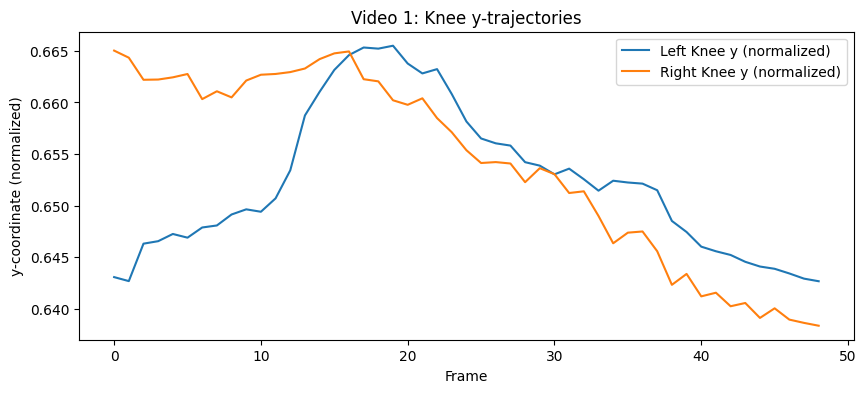

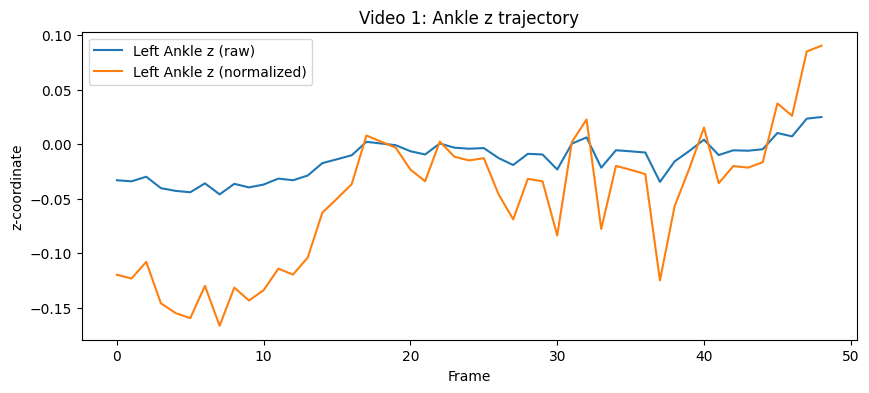

Pose min/max values after normalization:
x: -1.9608501762243082 0.28016057006147027
y: -1.7511006757997025 1.5867563972097443
z: -1.5905314393734622 1.3801347576661138


In [58]:
#Calling Sanity check function
pose = df_video.iloc[0]['pose']  # full (T,33,3)
sanity_check_pose(pose, title="Video 1")

In [69]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

def qc_gait_clip(clip, fps, visualize=False, title=""):

    GAIT_JOINTS = [
        2, 5,     # eyes
        11, 12,   # shoulders
        23, 24,   # hips
        25, 26,   # knees
        27, 28,   # ankles
        29, 30,   # heels
        31, 32    # foot index
    ]
    # Map to reduced clip indices (0–13)
    LEFT_HIP_IDX = GAIT_JOINTS.index(23)
    RIGHT_HIP_IDX = GAIT_JOINTS.index(24)
    LEFT_SHOULDER_IDX = GAIT_JOINTS.index(11)
    LEFT_KNEE_IDX = GAIT_JOINTS.index(25)
    LEFT_ANKLE_IDX = GAIT_JOINTS.index(27)

    qc = {}

    # Length
    qc["n_frames"] = clip.shape[0]
    qc["duration_s"] = clip.shape[0] / fps
    qc["flag_short"] = qc["n_frames"] < 40

    # Pelvis centering
    pelvis = (clip[:, LEFT_HIP_IDX] + clip[:, RIGHT_HIP_IDX]) / 2
    qc["pelvis_offset"] = np.linalg.norm(pelvis.mean(axis=0))
    qc["flag_off_center"] = qc["pelvis_offset"] > 0.05

    # Torso length
    torso = (clip[:, LEFT_SHOULDER_IDX] - pelvis)
    qc["torso_mean_length"] = np.linalg.norm(torso, axis=1).mean()

    # Smoothness (ankle Y)
    ankle_y = clip[:, LEFT_ANKLE_IDX, 1]
    qc["ankle_y_velocity_std"] = np.std(np.diff(ankle_y))
    qc["flag_jitter"] = qc["ankle_y_velocity_std"] > 0.15

    # Periodicity (knee Y)
    knee_y = clip[:, LEFT_KNEE_IDX, 1]
    peaks, _ = find_peaks(knee_y, distance=int(0.4*fps))
    qc["n_knee_peaks"] = len(peaks)
    qc["flag_no_periodicity"] = qc["n_knee_peaks"] < 1

    # Depth stability (ankle Z)
    ankle_z = clip[:, LEFT_ANKLE_IDX, 2]
    qc["ankle_z_range"] = ankle_z.max() - ankle_z.min()
    qc["ankle_z_spike"] = np.max(np.abs(np.diff(ankle_z)))
    qc["flag_flat_depth"] = qc["ankle_z_range"] < 0.1

    # Overall fail
    qc["qc_fail"] = any([
        qc["flag_short"],
        qc["flag_off_center"],
        qc["flag_jitter"],
        qc["flag_no_periodicity"],
        qc["flag_flat_depth"]
    ])

    # Optional plotting
    if visualize:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12,4))
        plt.subplot(1,2,1)
        plt.plot(knee_y)
        plt.title(f"{title} - Knee Y")
        plt.subplot(1,2,2)
        plt.plot(ankle_z)
        plt.title(f"{title} - Ankle Z")
        plt.show()

    return qc


In [84]:
qc_rows = []

for i, clip in enumerate(X_clips):
    qc = qc_gait_clip(clip, fps=60, visualize=False, title=f"Clip {i}")
    qc_rows.append(qc)

qc_df = pd.DataFrame(qc_rows)

# Summary
print("Total clips:", len(X_clips))
print("QC fail count:", qc_df["qc_fail"].sum())
print("QC fail %:", 100*qc_df["qc_fail"].mean())

qc_df[[
    'flag_short',
    'flag_off_center',
    'flag_jitter',
    'flag_no_periodicity',
    'flag_flat_depth'
]].sum()

Total clips: 1283
QC fail count: 1018
QC fail %: 79.34528448947779


flag_short               0
flag_off_center        963
flag_jitter              0
flag_no_periodicity      0
flag_flat_depth        260
dtype: int64

In [85]:
qc_rows = []

for i, clip in enumerate(X_clips_h):
    qc = qc_gait_clip(clip, fps=60, visualize=False, title=f"Clip {i}")
    qc_rows.append(qc)

qc_df = pd.DataFrame(qc_rows)

# Summary
print("Total clips:", len(X_clips_h))
print("QC fail count:", qc_df["qc_fail"].sum())
print("QC fail %:", 100*qc_df["qc_fail"].mean())

qc_df[[
    'flag_short',
    'flag_off_center',
    'flag_jitter',
    'flag_no_periodicity',
    'flag_flat_depth'
]].sum()




NameError: name 'X_clips_h' is not defined

array([[<Axes: title={'center': 'n_frames'}>,
        <Axes: title={'center': 'pelvis_offset'}>],
       [<Axes: title={'center': 'ankle_y_velocity_std'}>,
        <Axes: title={'center': 'n_knee_peaks'}>],
       [<Axes: title={'center': 'ankle_z_range'}>, <Axes: >]],
      dtype=object)

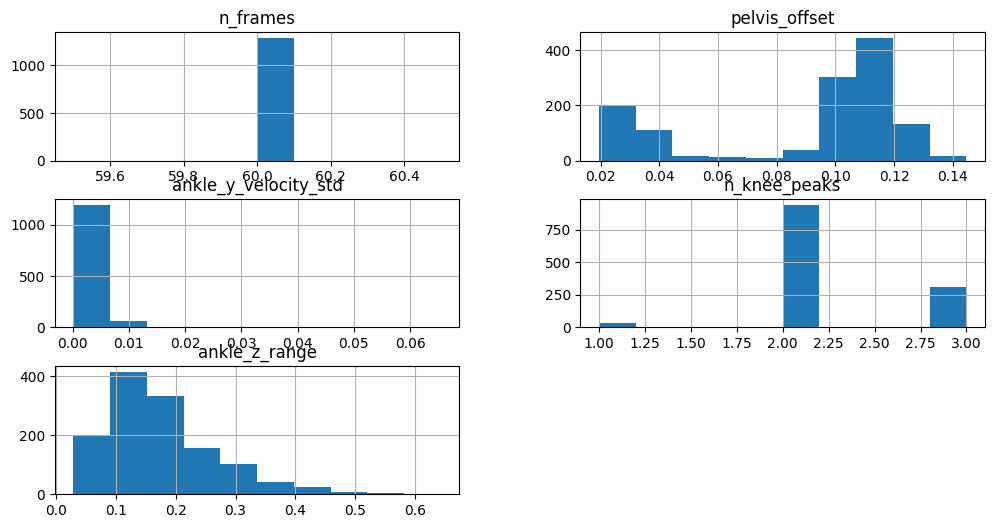

In [76]:

qc_df[['n_frames','pelvis_offset','ankle_y_velocity_std','n_knee_peaks','ankle_z_range']].hist(figsize=(12,6))

In [79]:
pd.crosstab(qc_df['flag_short'], qc_df['flag_no_periodicity'])



flag_no_periodicity,False
flag_short,
False,1283


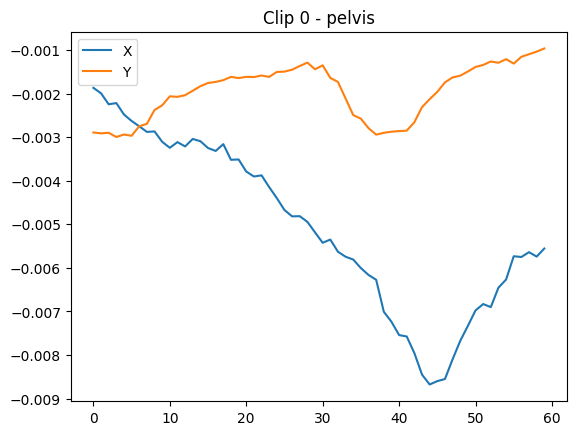

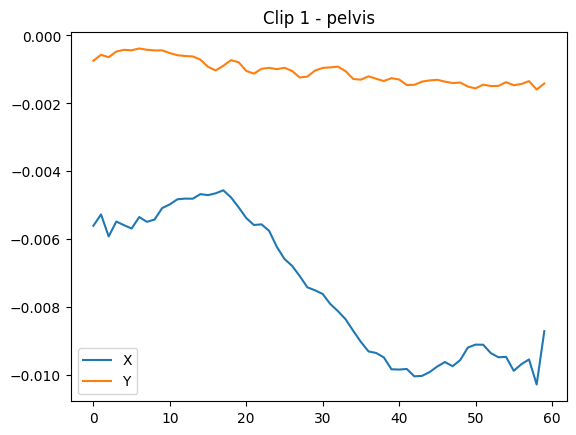

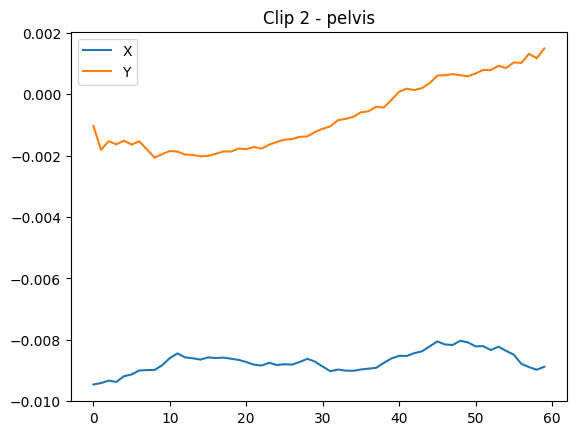

In [80]:
for i in qc_df[qc_df['flag_off_center']].index[:3]:
    clip = X_clips[i]
    pelvis = clip[:, GAIT_JOINTS.index(23)] + clip[:, GAIT_JOINTS.index(24)]
    pelvis /= 2
    plt.plot(pelvis[:,0], label="X")
    plt.plot(pelvis[:,1], label="Y")
    plt.title(f"Clip {i} - pelvis")
    plt.legend()
    plt.show()


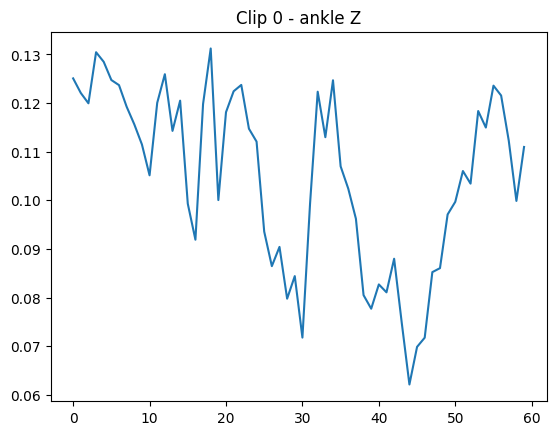

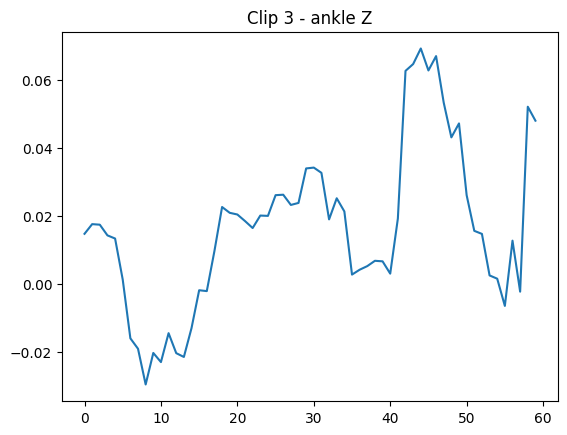

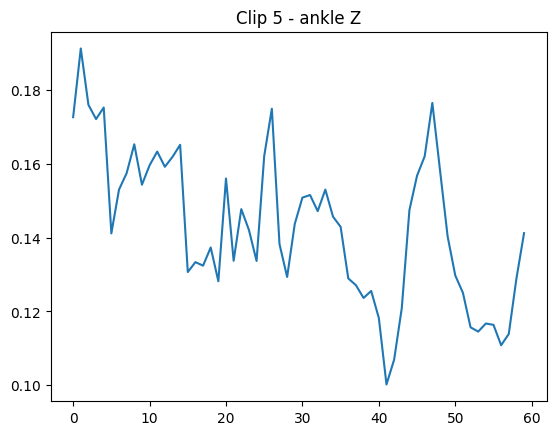

In [83]:
for i in qc_df[qc_df['flag_flat_depth']].index[:3]:
    clip = X_clips[i]
    ankle_z = clip[:, GAIT_JOINTS.index(27), 2]
    plt.plot(ankle_z)
    plt.title(f"Clip {i} - ankle Z")
    plt.show()


NameError: name 'pose_scaled' is not defined

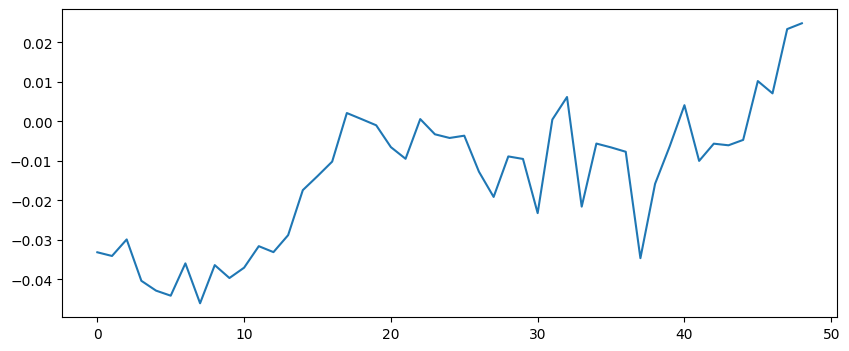

In [73]:
# c) Plot knee/ankle trajectories
# Check for sudden jumps or consistent scale:

# Example: left ankle (index 27) z-coordinate
plt.figure(figsize=(10,4))
plt.plot(pose[:, 27, 2], label="ankle z (raw)")
plt.plot(pose_scaled[:, 27, 2], label="ankle z (normalized)")
plt.xlabel("Frame")
plt.ylabel("z-coordinate")
plt.title("Ankle z trajectory: raw vs normalized")
plt.legend()
plt.show()


In [ ]:
#2. Sanity Checks:
# CHeck the hip centered trajectory oscillates around zeo
np.mean(pose_centered[:, left_hip], axis=0)
# should be close to [0, 0]

np.mean(np.linalg.norm(torso - pelvis, axis=1))
# should be ~1.0
    """
    Plot:
Knee trajectories from different subjects
They should be comparable in scale
    """
#check z coordinate is comparable to x,y, and tehre are no sudden jumps
plt.plot(pose[:, 27, 2], label="ankle z (raw)")
plt.plot(norm_pose[:, 27, 2], label="ankle z (normalized)")
plt.legend()

# pelvis should be near zero
np.mean(pose_scaled[:, [23, 24]], axis=(0,1))

# scale consistency
np.linalg.norm(pose_scaled[:, 11] - pose_scaled[:, 23], axis=1).mean()

In [ ]:
# READY for both approaches

#Feature-based ML (XGBoost / RF)
# Example reshape for feature extraction
clip = X_clips[0]  # (60, 33, 3)

# Deep Learning
X_dl = X_clips.reshape(len(X_clips), 60, -1)


We utilized the 3D output of MediaPipe Pose (x, y, z), where the z-dimension represents relative depth. All joints were pelvis-centered and scaled by torso length to ensure comparability across subjects.

In [ ]:
                ┌───────────────┐
30fps healthy → │ Pose sequence │
60fps pathology │  (T, J, 3)    │
                └──────┬────────┘
                       │
                       ▼
           ┌─────────────────────────┐
           │  Normalize Pose 3D      │
           │  - Pelvis-centered      │
           │  - Scaled by torso      │
           │  - Works for x, y, z   │
           └─────────┬──────────────┘
                     │
                     ▼
           ┌─────────────────────────┐
           │ Detect Heel Strikes      │
           │  - Use FPS from metadata │
           │  - Convert min_time → frames
           │  - Separate left/right │
           └─────────┬──────────────┘
                     │
                     ▼
           ┌─────────────────────────┐
           │ Extract Gait-Cycle Clips│
           │  - Each clip = 1–2 cycles│
           │  - Clips may vary in length│
           │  - Filter min/max frames │
           └─────────┬──────────────┘
                     │
                     ▼
           ┌─────────────────────────┐
           │ Resample Clips           │
           │  - Fixed number of frames│
           │  - Example: 60 frames   │
           │  - Works for 30fps & 60fps│
           └─────────┬──────────────┘
                     │
                     ▼
           ┌─────────────────────────┐
           │ Optional: Feature Calc  │
           │  - x, y, z coordinates  │
           │  - Velocity, acceleration│
           │  - Normalize by dt=1/fps│
           └─────────┬──────────────┘
                     │
                     ▼
           ┌─────────────────────────┐
           │ ML Model Input           │
           │  - Shape: (resample_frames, J*3) │
           │  - LSTM / Transformer / CNN │
           └─────────────────────────┘
